# Appendix D 两种采样顺序的 $a$、$e$ 分布

本 Notebook 使用同样的样本数和随机种子，对比两条彼此独立的采样路径：

1. **论文文字顺序**：先采样 $j$，再采样 $a\mid j$，用于复现 Fig. 19；
2. **严格联合分布的正常顺序**：先由 $P(a)=\int P(a,j)\,dj$ 采样 $a$，再采样 $j\mid a$。

两条路径都返回逐项对应的 $(a,j,e)$，其中 $e=\sqrt{1-j^2}$。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# 同时兼容从项目根目录或 notebooks 目录启动 Jupyter。
current_directory = Path.cwd().resolve()
project_directory = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)
if str(project_directory) not in sys.path:
    sys.path.insert(0, str(project_directory))

from p_a_j import (
    AU_PER_PC,
    sample_figure19_orbital_parameters,
    sample_initial_orbital_parameters,
)

In [2]:
# 固定种子使每次重新运行 Notebook 都得到相同的随机样本。
sample_count = 100_000
random_seed = 12345
paper_rng = np.random.default_rng(random_seed)

# 采样器使用论文写明的顺序：先采样 j，再对每个 j 从 P(a,j) 采样 a。
# Fig. 19 未公开的有效尺度集中定义在 p_a_j.py 中，没有在此处重复。
paper_samples = sample_figure19_orbital_parameters(
    sample_count=sample_count,
    rng=paper_rng,
)
paper_a_pc = paper_samples.semi_major_axis_pc
paper_e = paper_samples.eccentricity

In [3]:
paper_mean_a_pc = np.mean(paper_a_pc)
paper_mean_a_au = paper_mean_a_pc * AU_PER_PC
paper_mean_e = np.mean(paper_e)

print("论文文字顺序采样")
print(f"样本数 N = {paper_a_pc.size:,}")
print(f"a 的样本均值 = {paper_mean_a_pc:.8f} pc")
print(f"a 的样本均值 = {paper_mean_a_au:.2f} AU")
print(f"e 的样本均值 = {paper_mean_e:.8f}")

论文文字顺序采样
样本数 N = 100,000
a 的样本均值 = 0.03538599 pc
a 的样本均值 = 7298.88 AU
e 的样本均值 = 0.72458056


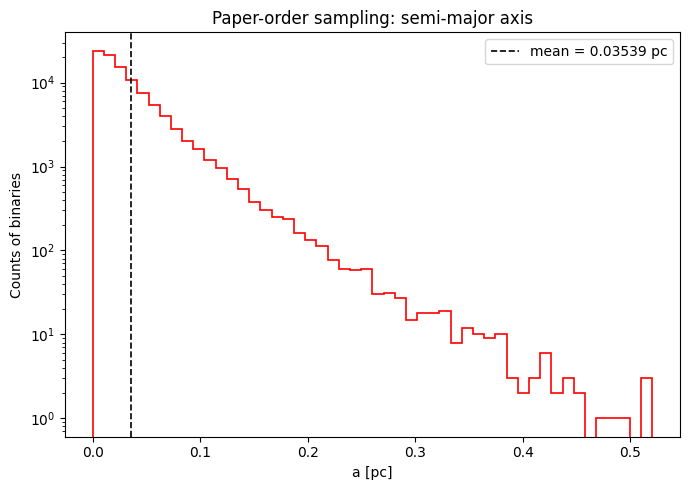

In [4]:
fig, ax = plt.subplots(figsize=(7.0, 5.0))

ax.hist(
    paper_a_pc,
    bins=50,
    histtype="step",
    color="red",
    linewidth=1.2,
)
ax.axvline(
    paper_mean_a_pc,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=fr"mean = {paper_mean_a_pc:.5f} pc",
)

ax.set_yscale("log")
ax.set_xlabel("a [pc]")
ax.set_ylabel("Counts of binaries")
ax.set_title("Paper-order sampling: semi-major axis")
ax.legend()
fig.tight_layout()
plt.show()

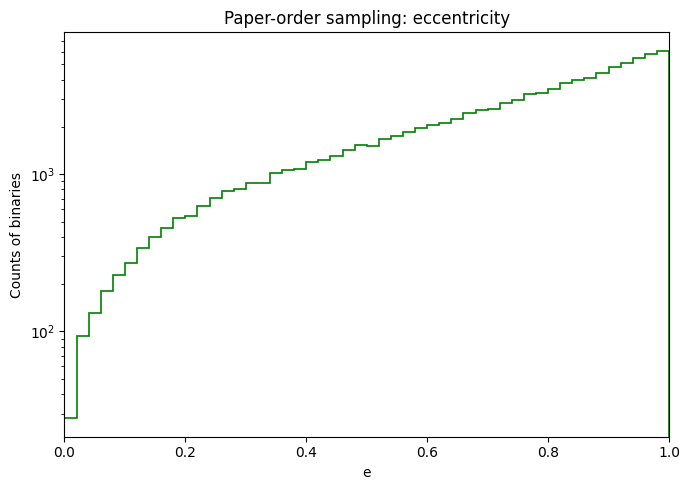

In [5]:
# 偏心率的定义域固定为 0<e<1，因此这里固定 50 个等宽 bin。
# 纵轴使用对数刻度，以便与论文 Fig. 19 下图的呈现方式对应。
eccentricity_bin_edges = np.linspace(0.0, 1.0, 51)

fig, ax = plt.subplots(figsize=(7.0, 5.0))
ax.hist(
    paper_e,
    bins=eccentricity_bin_edges,
    histtype="step",
    color="green",
    linewidth=1.2,
)
ax.set_yscale("log")
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("e")
ax.set_ylabel("Counts of binaries")
ax.set_title("Paper-order sampling: eccentricity")
fig.tight_layout()
plt.show()

## 严格联合分布的正常顺序：先采样 $a$，再采样 $j\mid a$

下面重新创建一个独立随机数生成器。它使用相同的种子，只是为了让两套结果各自可重复；不能把两个数组的第 $i$ 个样本理解成同一个双星。

In [6]:
strict_rng = np.random.default_rng(random_seed)
strict_samples = sample_initial_orbital_parameters(
    sample_count=sample_count,
    rng=strict_rng,
)
strict_a_pc = strict_samples.semi_major_axis_pc
strict_e = strict_samples.eccentricity

strict_mean_a_pc = np.mean(strict_a_pc)
strict_mean_a_au = strict_mean_a_pc * AU_PER_PC
strict_mean_e = np.mean(strict_e)

print("严格联合分布的正常顺序采样")
print(f"样本数 N = {strict_a_pc.size:,}")
print(f"a 的样本均值 = {strict_mean_a_pc:.8f} pc")
print(f"a 的样本均值 = {strict_mean_a_au:.2f} AU")
print(f"e 的样本均值 = {strict_mean_e:.8f}")

严格联合分布的正常顺序采样
样本数 N = 100,000
a 的样本均值 = 0.01054027 pc
a 的样本均值 = 2174.09 AU
e 的样本均值 = 0.88453859


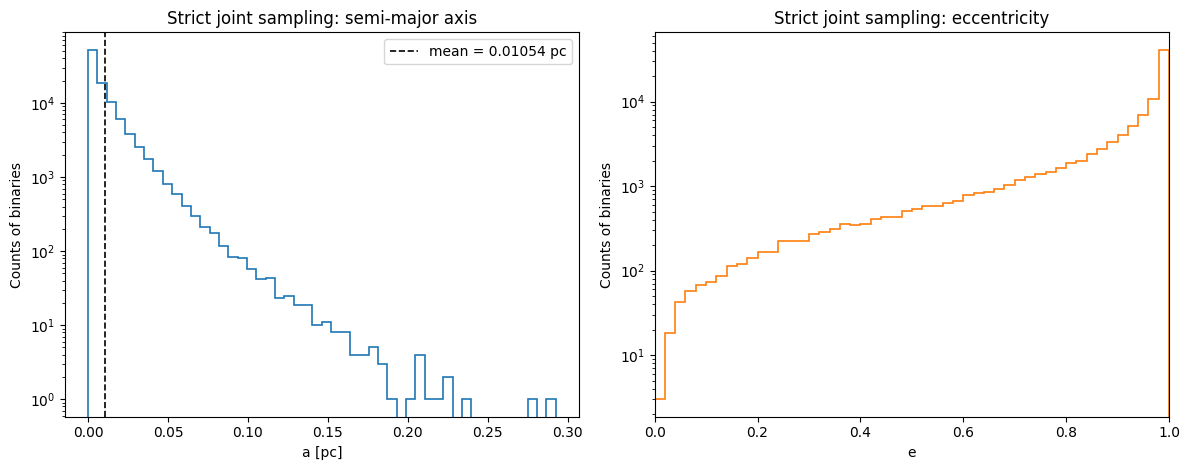

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

axes[0].hist(
    strict_a_pc,
    bins=50,
    histtype="step",
    color="tab:blue",
    linewidth=1.2,
)
axes[0].axvline(
    strict_mean_a_pc,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=fr"mean = {strict_mean_a_pc:.5f} pc",
)
axes[0].set_yscale("log")
axes[0].set_xlabel("a [pc]")
axes[0].set_ylabel("Counts of binaries")
axes[0].set_title("Strict joint sampling: semi-major axis")
axes[0].legend()

axes[1].hist(
    strict_e,
    bins=eccentricity_bin_edges,
    histtype="step",
    color="tab:orange",
    linewidth=1.2,
)
axes[1].set_yscale("log")
axes[1].set_xlim(0.0, 1.0)
axes[1].set_xlabel("e")
axes[1].set_ylabel("Counts of binaries")
axes[1].set_title("Strict joint sampling: eccentricity")

fig.tight_layout()
plt.show()